# MyRecs — Google Colab (single notebook)

1. **Upload this file only** to [Google Colab](https://colab.research.google.com/).
2. **Runtime → Run all** (or **Runtime → Run anyway** if prompted).

This notebook installs dependencies, creates a synthetic dataset (150 items), evaluates **TF-IDF**, **matrix factorization**, and **sentence embeddings**, and plots results. **No zip file and no project folder** — everything runs in Colab.

*First run downloads the embedding model (~90MB) and may take several minutes.*


In [1]:
%pip install -q pandas "numpy>=1.24" "scikit-learn>=1.3" sentence-transformers torch matplotlib seaborn


In [2]:
# MyRecs standalone library (single notebook — no zip / no src folder)
from __future__ import annotations

import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Colab uses /content; local Jupyter uses a folder next to CWD
if Path("/content").exists():
    DATA_ROOT = Path("/content/myrecs_data")
else:
    DATA_ROOT = (Path.cwd() / "myrecs_data").resolve()
RATINGS_CSV = DATA_ROOT / "my_ratings.csv"
DEFAULT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
SYNTH_USER_COUNT = 55
SEED_COLLAB = 123


def ensure_dirs() -> None:
    DATA_ROOT.mkdir(parents=True, exist_ok=True)


def text_for_tfidf(row: pd.Series) -> str:
    cats = str(row.get("categories", "") or "")
    rev = str(row.get("short_review", "") or "")
    return f"{cats} {rev}"


def text_for_embedding(row: pd.Series) -> str:
    title = str(row.get("title", "") or "")
    cats = str(row.get("categories", "") or "")
    rev = str(row.get("short_review", "") or "")
    return f"{title}. Genres: {cats}. Review: {rev}"


def train_test_split_items(
    df: pd.DataFrame, test_fraction: float = 0.2, random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.RandomState(random_state)
    df = df.copy()
    df["_bucket"] = pd.cut(df["my_rating"], bins=[0, 4, 7, 10], labels=[0, 1, 2])
    test_idx: list[int] = []
    for _, part in df.groupby("_bucket", observed=False):
        part = part.sample(frac=1.0, random_state=rng)
        n_test = max(1, int(len(part) * test_fraction))
        test_idx.extend(part.head(n_test).index.tolist())
    test_mask = df.index.isin(test_idx)
    train_df = df.loc[~test_mask].drop(columns=["_bucket"], errors="ignore")
    test_df = df.loc[test_mask].drop(columns=["_bucket"], errors="ignore")
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


def precision_recall_at_k(
    recommended_ids: list[int], relevant_ids: set[int], k: int = 5
) -> tuple[float, float]:
    topk = recommended_ids[:k]
    hits = sum(1 for i in topk if i in relevant_ids)
    prec = hits / k if k else 0.0
    rel_count = len(relevant_ids)
    rec = hits / rel_count if rel_count else 0.0
    return prec, rec


def avg_rating_top_n(
    ranked_ids: list[int], id_to_rating: dict[int, float], n: int = 10
) -> float:
    vals = [float(id_to_rating[iid]) for iid in ranked_ids[:n] if iid in id_to_rating]
    return float(np.mean(vals)) if vals else 0.0


def generate_dataset(n_items: int = 150, seed: int = 42) -> pd.DataFrame:
    rng = random.Random(seed)
    ensure_dirs()
    types_pool = (
        ["movie"] * 45 + ["series"] * 35 + ["book"] * 30
        + ["youtube"] * 22 + ["song"] * 18
    )
    rng.shuffle(types_pool)
    genre_sets = [
        "action,thriller", "drama,character-study", "sci-fi,mystery", "comedy,feel-good",
        "horror,suspense", "documentary,real-life", "fantasy,adventure", "romance,drama",
        "animation,family", "biography,inspirational", "crime,noir", "musical,emotion",
        "youtube,tech,motivational", "youtube,productivity,self-improvement",
        "indie,experimental", "war,historical", "mystery,psychological", "sci-fi,philosophy",
        "sports,drama", "music,indie,lyrical",
    ]
    titles_by_type = {
        "movie": [
            "Neon Drift", "The Quiet Ledger", "Midnight in Oslo", "Steel Harbor",
            "Echoes of Tomorrow", "Paper Planes", "The Last Lighthouse",
            "Velvet Run", "Cold Signal", "Garden of Faults",
        ],
        "series": [
            "Northbound", "The Archive Room", "Small Hours", "Signal Nine",
            "Copper Street", "After the Flood", "The Long Weekend",
            "Parallel Lines", "Blue Hour", "The Workshop",
        ],
        "book": [
            "The Weight of Water", "Maps We Burn", "Slow Lightning",
            "Letters from the Edge", "The Habits of Rivers",
            "Night School for Dreamers", "Salt and Syntax",
        ],
        "youtube": [
            "Deep Work in a Distracted World",
            "How I Learned to Code in 6 Months",
            "The Psychology of Habits Explained Simply",
            "Minimal Desk Setup Tour 2025",
            "Why We Procrastinate and What Helps",
        ],
        "song": [
            "Satellite Static", "Golden Hour Drive", "Neon Cathedral",
            "Paper Hearts", "Midnight Metro", "Echo Chamber Blues",
        ],
    }
    templates = [
        "Honestly better than I expected — stayed with me for days.",
        "A bit uneven in the middle but the ending landed hard.",
        "Exactly my vibe when I need something {adj}.",
        "Not perfect, but the {genre} energy is undeniable.",
        "Would recommend if you like {genre} with a personal touch.",
        "This hit different; surprisingly personal.",
        "Mixed feelings: great {genre}, messy pacing.",
    ]
    rows = []
    used_titles: set[str] = set()
    tid_counters = {k: 0 for k in titles_by_type}

    def next_title(kind: str) -> str:
        pool = titles_by_type[kind]
        base = pool[tid_counters[kind] % len(pool)]
        tid_counters[kind] += 1
        suf = tid_counters[kind] // len(pool)
        name = f"{base}" if suf == 0 else f"{base} ({suf})"
        if name in used_titles:
            name = f"{base} — {tid_counters[kind]}"
        used_titles.add(name)
        return name

    def sample_rating() -> int:
        r = rng.random()
        if r < 0.42:
            return rng.randint(8, 10)
        if r < 0.72:
            return rng.randint(6, 8)
        if r < 0.92:
            return rng.randint(4, 6)
        return rng.randint(1, 3)

    for i in range(1, n_items + 1):
        kind = types_pool[(i - 1) % len(types_pool)]
        title = next_title(kind)
        gbase = rng.choice(genre_sets)
        extra = rng.choice(
            ["motivational", "nostalgic", "slow-burn", "fast-paced", "cerebral", "cozy", "dark"]
        )
        categories = f"{kind},{gbase},{extra}"
        rating = sample_rating()
        primary_genre = gbase.split(",")[0]
        t = rng.choice(templates)
        adj = "thoughtful" if rating >= 7 else "different"
        review = t.format(adj=adj, genre=primary_genre.strip())
        rows.append({
            "item_id": i,
            "title": title,
            "categories": categories,
            "my_rating": rating,
            "short_review": review,
        })
    out = pd.DataFrame(rows)
    out.to_csv(RATINGS_CSV, index=False)
    return out


def recommend_content_based(train_df, candidate_df, top_n: int):
    combined = pd.concat([train_df, candidate_df], axis=0, ignore_index=True)
    n_train = len(train_df)
    corpus = [text_for_tfidf(combined.iloc[i]) for i in range(len(combined))]
    vectorizer = TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2), min_df=1, stop_words="english"
    )
    mat = vectorizer.fit_transform(corpus)
    train_mat = mat[:n_train]
    cand_mat = mat[n_train:]
    ratings = train_df["my_rating"].astype(float).values
    w = np.maximum(ratings - 4.0, 0.1)
    w = w / (w.sum() + 1e-9)
    profile = np.asarray(w @ train_mat.toarray()).reshape(1, -1)
    sims = cosine_similarity(cand_mat, profile).ravel()
    order = np.argsort(-sims)
    cand_ids = candidate_df["item_id"].astype(int).values
    ranked_ids = [int(cand_ids[i]) for i in order]
    scores = [float(sims[i]) for i in order]
    return ranked_ids[:top_n], sims, scores[:top_n]


def rank_all_items_content(train_df, cand_df, top_n: int):
    if cand_df.empty:
        return [], {}
    ranked, _, scores = recommend_content_based(train_df, cand_df, top_n=len(cand_df))
    return ranked[:top_n], dict(zip(ranked, scores))


def _synthetic_ratings(item_ids, id_to_r, n_users, seed=SEED_COLLAB):
    rng = random.Random(seed)
    rows = []
    vals = list(id_to_r.values())
    mu = float(np.mean(vals)) if vals else 6.0
    for u in range(1, n_users + 1):
        n_r = rng.randint(25, 90)
        picked = rng.sample(item_ids, min(n_r, len(item_ids)))
        for it in picked:
            base = id_to_r.get(it, mu)
            noise = rng.gauss(0, 1.4)
            r = float(np.clip(base + noise, 1.0, 10.0))
            rows.append((u, it, round(r, 1)))
    return rows


def build_augmented_rows(train_df, all_item_ids=None, n_synth=SYNTH_USER_COUNT, seed=SEED_COLLAB):
    train_items = train_df["item_id"].astype(int).tolist()
    id_to_r = dict(zip(train_df["item_id"].astype(int), train_df["my_rating"].astype(float)))
    mu = float(train_df["my_rating"].mean())
    pool = list(dict.fromkeys((all_item_ids or train_items) + train_items))
    for iid in pool:
        id_to_r.setdefault(int(iid), mu)
    rows = [(0, int(r["item_id"]), float(r["my_rating"])) for _, r in train_df.iterrows()]
    rows.extend(_synthetic_ratings(pool, id_to_r, n_synth, seed=seed))
    return rows


@dataclass
class BiasedMF:
    n_factors: int = 20
    n_epochs: int = 40
    lr: float = 0.02
    reg: float = 0.06
    random_state: int = SEED_COLLAB
    mu: float = 0.0
    bu: Optional[np.ndarray] = None
    bi: Optional[np.ndarray] = None
    p: Optional[np.ndarray] = None
    q: Optional[np.ndarray] = None
    user_map: Optional[dict] = None
    item_map: Optional[dict] = None

    def fit(self, rows):
        rng = np.random.RandomState(self.random_state)
        users = sorted({u for u, _, _ in rows})
        items = sorted({i for _, i, _ in rows})
        self.user_map = {u: idx for idx, u in enumerate(users)}
        self.item_map = {i: idx for idx, i in enumerate(items)}
        n_u, n_i = len(users), len(items)
        self.mu = float(np.mean([r for _, _, r in rows]))
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.p = rng.normal(0, 0.1, size=(n_u, self.n_factors))
        self.q = rng.normal(0, 0.1, size=(n_i, self.n_factors))
        for _ in range(self.n_epochs):
            rng.shuffle(rows)
            for u_raw, i_raw, r in rows:
                u = self.user_map[u_raw]
                i = self.item_map[i_raw]
                pred = self.mu + self.bu[u] + self.bi[i] + float(self.p[u].dot(self.q[i]))
                err = r - pred
                bu_old, bi_old = self.bu[u], self.bi[i]
                self.bu[u] += self.lr * (err - self.reg * bu_old)
                self.bi[i] += self.lr * (err - self.reg * bi_old)
                pu, qi = self.p[u].copy(), self.q[i].copy()
                self.p[u] += self.lr * (err * qi - self.reg * pu)
                self.q[i] += self.lr * (err * pu - self.reg * qi)
        return self

    def predict(self, raw_uid: int, raw_iid: int) -> float:
        assert self.user_map is not None and self.item_map is not None
        if raw_uid not in self.user_map or raw_iid not in self.item_map:
            return self.mu
        u, i = self.user_map[raw_uid], self.item_map[raw_iid]
        est = self.mu + self.bu[u] + self.bi[i] + float(self.p[u].dot(self.q[i]))
        return float(np.clip(est, 1.0, 10.0))


def train_svd(train_df, all_item_ids=None):
    rows = build_augmented_rows(train_df, all_item_ids=all_item_ids)
    return BiasedMF().fit(rows)


def rank_candidates_svd(model, candidate_item_ids, raw_uid=0, top_n=10):
    scores = {iid: model.predict(raw_uid, iid) for iid in candidate_item_ids}
    ranked = sorted(scores.keys(), key=lambda x: scores[x], reverse=True)
    return ranked[:top_n], scores


def get_device() -> str:
    try:
        import torch
        return "cuda" if torch.cuda.is_available() else "cpu"
    except ImportError:
        return "cpu"


def encode_dataframe(df: pd.DataFrame, model_name: str = DEFAULT_MODEL_NAME, batch_size: int = 32):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name, device=get_device())
    texts = [text_for_embedding(df.iloc[i]) for i in range(len(df))]
    return np.asarray(
        model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
    )


def rank_all_embedding(train_df, cand_df, model_name=DEFAULT_MODEL_NAME, top_n=10):
    if cand_df.empty:
        return [], {}
    combined = pd.concat([train_df, cand_df], axis=0, ignore_index=True)
    n_train = len(train_df)
    emb = encode_dataframe(combined, model_name=model_name)
    train_e, cand_e = emb[:n_train], emb[n_train:]
    ratings = train_df["my_rating"].astype(float).values
    w = np.maximum(ratings - 4.0, 0.1)
    w = w / (w.sum() + 1e-9)
    profile = np.average(train_e, axis=0, weights=w).reshape(1, -1)
    sims = cosine_similarity(cand_e, profile).ravel()
    order = np.argsort(-sims)
    cand_ids = cand_df["item_id"].astype(int).values
    ranked = [int(cand_ids[i]) for i in order]
    scores = {int(cand_ids[i]): float(sims[i]) for i in range(len(cand_ids))}
    return ranked[:top_n], scores


sns.set_theme(style="whitegrid")
print("Ready. Data:", DATA_ROOT, "| Device (embeddings):", get_device())


Ready. Data: /content/myrecs_data | Device (embeddings): cpu


## Load data


In [3]:
# Load or generate data
ensure_dirs()
if not RATINGS_CSV.exists():
    generate_dataset()
df = pd.read_csv(RATINGS_CSV)
df["item_id"] = df["item_id"].astype(int)
df["my_rating"] = pd.to_numeric(df["my_rating"], errors="coerce")
print(f"Loaded {len(df)} items from", RATINGS_CSV)
display(df.head())


Loaded 150 items from /content/myrecs_data/my_ratings.csv


,item_id,title,categories,my_rating,short_review
0,1,Northbound,"series,animation,family,cerebral",6,Honestly better than I expected — stayed with ...
1,2,Satellite Static,"song,biography,inspirational,dark",8,A bit uneven in the middle but the ending land...
2,3,The Weight of Water,"book,horror,suspense,slow-burn",6,"Mixed feelings: great horror, messy pacing."
3,4,Golden Hour Drive,"song,mystery,psychological,motivational",7,Honestly better than I expected — stayed with ...
4,5,The Archive Room,"series,comedy,feel-good,slow-burn",5,A bit uneven in the middle but the ending land...


## Metrics


In [4]:
# Train/test split and metrics (relevant = rating >= 7 on hold-out items)
train_df, test_df = train_test_split_items(df, test_fraction=0.2, random_state=42)
REL_THRESHOLD = 7.0
relevant = set(test_df.loc[test_df["my_rating"] >= REL_THRESHOLD, "item_id"].astype(int))
id_to_rating = dict(zip(df["item_id"].astype(int), df["my_rating"].astype(float)))
test_ids = test_df["item_id"].astype(int).tolist()
all_ids = df["item_id"].astype(int).tolist()
print(len(train_df), "train,", len(test_df), "test | relevant in test:", len(relevant))

ranked_c, _ = rank_all_items_content(train_df, test_df, top_n=len(test_df))
p5, r5 = precision_recall_at_k(ranked_c, relevant, k=5)
a10 = avg_rating_top_n(ranked_c, id_to_rating, n=10)
print(f"TF-IDF   P@5={p5:.4f}  R@5={r5:.4f}  AvgTop10={a10:.4f}")

svd_model = train_svd(train_df, all_item_ids=all_ids)
ranked_s, _ = rank_candidates_svd(svd_model, test_ids, raw_uid=0, top_n=len(test_ids))
p5s, r5s = precision_recall_at_k(ranked_s, relevant, k=5)
a10s = avg_rating_top_n(ranked_s, id_to_rating, n=10)
print(f"MF/SVD   P@5={p5s:.4f}  R@5={r5s:.4f}  AvgTop10={a10s:.4f}")

print("Encoder:", get_device(), "| loading MiniLM (first run downloads weights)...")
ranked_e, _ = rank_all_embedding(train_df, test_df, model_name=DEFAULT_MODEL_NAME, top_n=len(test_df))
p5e, r5e = precision_recall_at_k(ranked_e, relevant, k=5)
a10e = avg_rating_top_n(ranked_e, id_to_rating, n=10)
print(f"Embedding P@5={p5e:.4f}  R@5={r5e:.4f}  AvgTop10={a10e:.4f}")


121 train, 29 test | relevant in test: 18
TF-IDF   P@5=1.0000  R@5=0.2778  AvgTop10=6.7000
MF/SVD   P@5=0.6000  R@5=0.1667  AvgTop10=7.0000
Encoder: cpu | loading MiniLM (first run downloads weights)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding P@5=0.4000  R@5=0.1111  AvgTop10=7.1000


## Plots


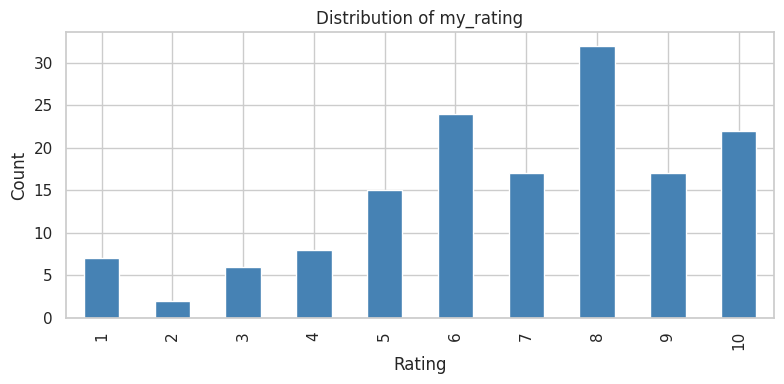

,P@5,R@5,AvgTop10
TF-IDF,1.0,0.277778,6.7
MF,0.6,0.166667,7.0
Embedding,0.4,0.111111,7.1


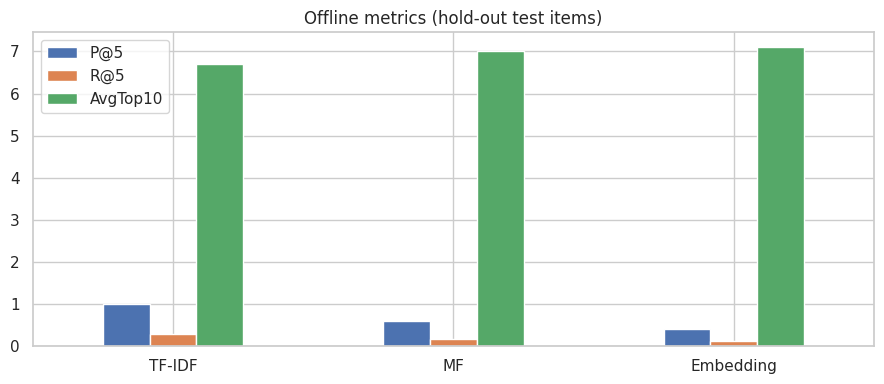

In [5]:
# Figures
fig, ax = plt.subplots(figsize=(8, 4))
df["my_rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Distribution of my_rating")
plt.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        "P@5": [p5, p5s, p5e],
        "R@5": [r5, r5s, r5e],
        "AvgTop10": [a10, a10s, a10e],
    },
    index=["TF-IDF", "MF", "Embedding"],
)
display(summary)
summary.plot(kind="bar", figsize=(9, 4), rot=0)
plt.title("Offline metrics (hold-out test items)")
plt.tight_layout()
plt.show()


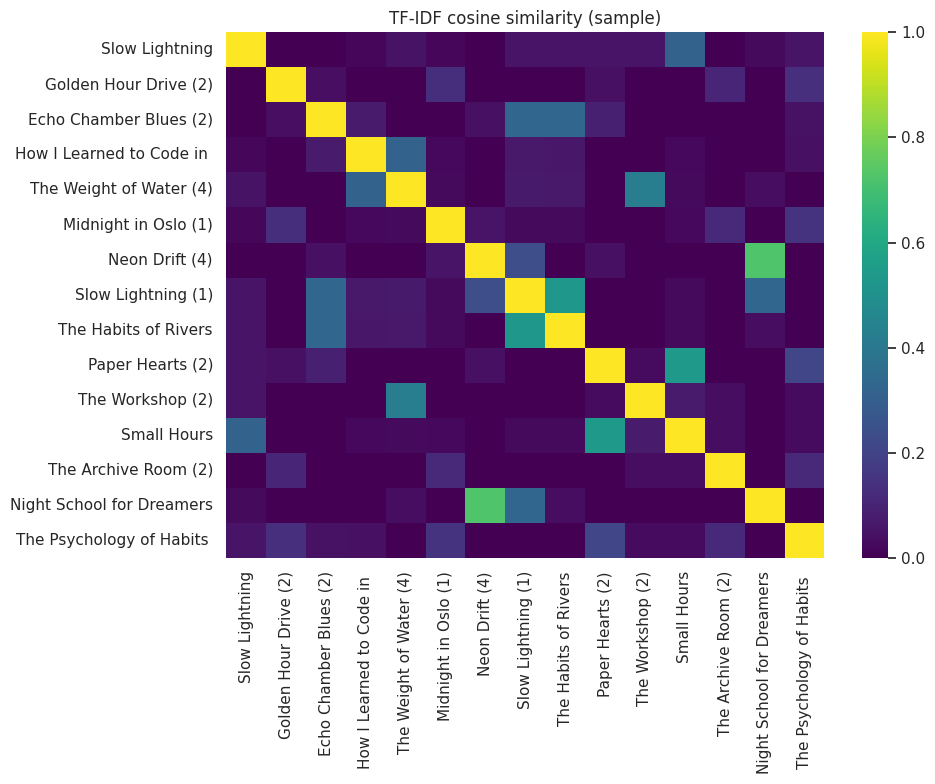

In [6]:
# TF-IDF similarity heatmap (random sample)
from sklearn.feature_extraction.text import TfidfVectorizer as TV
from sklearn.metrics.pairwise import cosine_similarity as csim

sample = df.sample(n=min(15, len(df)), random_state=1).reset_index(drop=True)
corpus = [text_for_tfidf(sample.iloc[i]) for i in range(len(sample))]
vec = TV(max_features=2000, ngram_range=(1, 2), min_df=1, stop_words="english")
X = vec.fit_transform(corpus)
S = csim(X)
labels = sample["title"].str[:25].tolist()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(S, xticklabels=labels, yticklabels=labels, cmap="viridis", ax=ax)
ax.set_title("TF-IDF cosine similarity (sample)")
plt.tight_layout()
plt.show()
